# Bandwidth Tunning Notebook Reproduction

This notebook reproduces the core workflow of this folder without writing PNG or CSV artifacts to disk. It keeps the default configuration values in memory, loads the dataset through the project code, runs the bandwidth sweep, and displays the plots inline.

The default configuration below matches `configs/defaults.json`: `kmnist28`, one experiment, 30 bandwidth points, 5 seeds, `train_sample=80`, `test_sample=20`, and `dimension=4`.

In [1]:
import json
from copy import deepcopy

import matplotlib.pyplot as plt
import merlin
import numpy as np
import sklearn
import torch

from lib.imports import data
from lib.metrics import (
    RBF,
    RBF_2,
    calculate_eta_max,
    calculate_g,
    calculate_kernel_distance_F,
    fidelity_kernel,
    projected_fidelity_kernel,
)
from lib.runner import subset_PCA

In [2]:
DEFAULT_CFG = {
    "description": "This is the default configuration file for Bandwidth Tunning.",
    "seed": 42,
    "outdir": "outdir",
    "device": "cpu",
    "dataset": {
        "name": "kmnist28",
        "root": "data",
    },
    "number_of_modes": 4,
    "logging": {
        "level": "INFO",
        "save_config_snapshot": True,
    },
    "graph_name": "Fig 3 - Test configuration",
    "graphs": {
        "min": -2.3,
        "max": 0.6,
        "number_of_points": 30,
    },
    "figs": [
        "Variances",
        "Geometric_distance",
        "Frobenius_distance",
        "Eta_max",
        "ROC_AUC",
    ],
    "experiments": [
        {
            "projected": False,
            "train_sample": 80,
            "test_sample": 20,
            "description": "4 kmnist28 80-20",
            "dimension": 4,
            "nb_seeds": 5,
        }
    ],
}

cfg = deepcopy(DEFAULT_CFG)
print(json.dumps(cfg, indent=2))

{
  "description": "This is the default configuration file for Bandwidth Tunning.",
  "seed": 42,
  "outdir": "outdir",
  "device": "cpu",
  "dataset": {
    "name": "kmnist28",
    "root": "data"
  },
  "number_of_modes": 4,
  "logging": {
    "level": "INFO",
    "save_config_snapshot": true
  },
  "graph_name": "Fig 3 - Test configuration",
  "graphs": {
    "min": -2.3,
    "max": 0.6,
    "number_of_points": 30
  },
  "figs": [
    "Variances",
    "Geometric_distance",
    "Frobenius_distance",
    "Eta_max",
    "ROC_AUC"
  ],
  "experiments": [
    {
      "projected": false,
      "train_sample": 80,
      "test_sample": 20,
      "description": "4 kmnist28 80-20",
      "dimension": 4,
      "nb_seeds": 5
    }
  ]
}


In [3]:
class Result:
    def __init__(self, g, var_FQK, var_RBF, F, eta_max_Q, eta_max_C, ROC_AUC):
        self.g = g
        self.var_FQK = var_FQK
        self.var_RBF = var_RBF
        self.F = F
        self.eta_max_Q = eta_max_Q
        self.eta_max_C = eta_max_C
        self.ROC_AUC = ROC_AUC


def train_one_bandwidth(feature_map, X_train, y_train_1D, X_test, y_test_1D, bandwidth=1.0, projected=False):
    X_train = X_train * bandwidth
    X_test = X_test * bandwidth

    if not projected:
        K_train = fidelity_kernel(feature_map, X_train)
        K_test = fidelity_kernel(feature_map, X_train, X_test)
        K_rbf = RBF(X_train)
    else:
        K_train = projected_fidelity_kernel(feature_map, X_train)
        K_test = projected_fidelity_kernel(feature_map, X_train, X_test)
        K_rbf = RBF_2(X_train)

    svc = sklearn.svm.SVC(kernel="precomputed")
    svc.fit(K_train.detach().numpy(), y_train_1D.detach().numpy())

    g = calculate_g(K_rbf, K_train)
    F = calculate_kernel_distance_F(K_rbf, K_train)
    eta_max_Q = calculate_eta_max(K_train)
    eta_max_C = calculate_eta_max(K_rbf)

    y_test_np = y_test_1D.detach().numpy()
    decision_scores = svc.decision_function(K_test.detach().numpy())
    if np.unique(y_test_np).size < 2:
        roc_auc = np.nan
    else:
        roc_auc = sklearn.metrics.roc_auc_score(y_test_np, decision_scores)

    return Result(
        g.item(),
        K_train.var(correction=False).item(),
        K_rbf.var(correction=False).item(),
        F.item(),
        eta_max_Q.item(),
        eta_max_C.item(),
        roc_auc,
    )


def run_notebook_experiment(cfg):
    sweep = cfg["graphs"]
    bandwidths = np.logspace(sweep["min"], sweep["max"], sweep["number_of_points"])
    experiment_summaries = []

    X_train_full, y_train_full, X_test_full, y_test_full = data(cfg["dataset"]["name"])

    for exp in cfg["experiments"]:
        seed_values = np.random.default_rng(cfg["seed"]).integers(
            low=0, high=10000, size=exp["nb_seeds"]
        )

        metrics = {
            "g": np.zeros_like(bandwidths),
            "var_FQK": np.zeros_like(bandwidths),
            "var_RBF": np.zeros_like(bandwidths),
            "F": np.zeros_like(bandwidths),
            "eta_max_Q": np.zeros_like(bandwidths),
            "eta_max_C": np.zeros_like(bandwidths),
            "ROC_AUC": np.zeros_like(bandwidths),
        }

        for seed_value in seed_values:
            X_train, y_train, X_test, y_test = subset_PCA(
                X_train_full,
                y_train_full,
                X_test_full,
                y_test_full,
                nb_train=exp["train_sample"],
                nb_test=exp["test_sample"],
                dim=exp["dimension"],
                seed=int(seed_value),
            )

            builder = merlin.CircuitBuilder(n_modes=X_train.shape[1] + 1)
            builder.add_entangling_layer(trainable=True, model="mzi", name="left")
            builder.add_angle_encoding(modes=range(X_train.shape[1]), name="phi")
            builder.add_entangling_layer(trainable=True, model="mzi", name="right")
            feature_map = merlin.FeatureMap(
                builder=builder,
                input_size=X_train.shape[1],
                input_parameters="phi",
            )

            for index, bandwidth in enumerate(bandwidths):
                result = train_one_bandwidth(
                    feature_map,
                    X_train,
                    y_train,
                    X_test,
                    y_test,
                    bandwidth=bandwidth,
                    projected=exp["projected"],
                )
                metrics["g"][index] += result.g
                metrics["var_FQK"][index] += result.var_FQK
                metrics["var_RBF"][index] += result.var_RBF
                metrics["F"][index] += result.F
                metrics["eta_max_Q"][index] += result.eta_max_Q
                metrics["eta_max_C"][index] += result.eta_max_C
                metrics["ROC_AUC"][index] += result.ROC_AUC

        for key in metrics:
            metrics[key] /= len(seed_values)

        experiment_summaries.append({
            "description": exp["description"],
            "dimension": exp["dimension"],
            "projected": exp["projected"],
            "bandwidths": bandwidths,
            "metrics": metrics,
        })

    return experiment_summaries


def plot_experiment_summaries(cfg, experiment_summaries):
    plot_names = cfg["figs"]
    n_plots = len(plot_names)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    colors = ["#f0b593", "#d65f49", "#a33f5f", "#662248", "#4a2a5f", "#2b1b36"]

    for plot_index, plot_name in enumerate(plot_names):
        ax = axes[plot_index]

        for exp_index, summary in enumerate(experiment_summaries):
            color = colors[exp_index % len(colors)]
            x = summary["bandwidths"]
            metrics = summary["metrics"]
            is_projected = bool(summary["projected"])
            quantum_label = "PQK" if is_projected else "FQK"
            classical_label = "RBF_2" if is_projected else "RBF"
            legend = str(summary["dimension"])

            if plot_name == "Variances":
                ax.loglog(x, metrics["var_FQK"], label=f"{quantum_label} ({legend})", color=color, linestyle="-", linewidth=3)
                ax.loglog(x, metrics["var_RBF"], label=f"{classical_label} ({legend})", color=color, linestyle="--", linewidth=3)
                ax.set_title("Kernel variances")
                ax.set_ylabel(r"$Var_D[\mathbf{K}]$")
                ax.set_ylim(bottom=1e-10, top=1e4)
            elif plot_name == "Geometric_distance":
                ax.loglog(x, metrics["g"], label=legend, color=color, linestyle="-", linewidth=3)
                ax.set_ylabel(r"$g(\mathbf{K}_C, \mathbf{K}_Q)$")
                ax.set_ylim(bottom=5e-1, top=1e3)
            elif plot_name == "Frobenius_distance":
                ax.loglog(x, metrics["F"], label=legend, color=color, linestyle="-", linewidth=3)
                ax.set_ylabel(r"$F(\mathbf{K}_C, \mathbf{K}_Q)$")
                ax.set_ylim(bottom=1e-3, top=1e3)
            elif plot_name == "Eta_max":
                ax.loglog(x, metrics["eta_max_Q"], label=f"eta_max_{quantum_label} ({legend})", color=color, linestyle="-", linewidth=3)
                ax.loglog(x, metrics["eta_max_C"], label=f"eta_max_{classical_label} ({legend})", color=color, linestyle="--", linewidth=3)
                ax.set_ylabel(r"$\eta_{max(K)}$")
                ax.set_ylim(bottom=1e-3, top=1e5)
            elif plot_name == "ROC_AUC":
                ax.semilogx(x, metrics["ROC_AUC"], label=legend, color=color, linestyle="-", linewidth=3)
                ax.set_ylabel("roc auc score")
            else:
                raise ValueError(f"Unsupported plot name: {plot_name}")

        ax.set_xlabel(r"Bandwidth $c$")
        ax.legend()
        ax.grid(True, which="both", ls="--", alpha=0.5)

    fig.suptitle(cfg["graph_name"])
    plt.tight_layout()
    plt.show()

In [4]:
experiment_summaries = run_notebook_experiment(cfg)



for summary in experiment_summaries:

    print(summary["description"])

    print("  bandwidth points:", len(summary["bandwidths"]))

    print("  metrics:", ", ".join(summary["metrics"].keys()))


4 kmnist28 80-20
  bandwidth points: 30
  metrics: g, var_FQK, var_RBF, F, eta_max_Q, eta_max_C, ROC_AUC


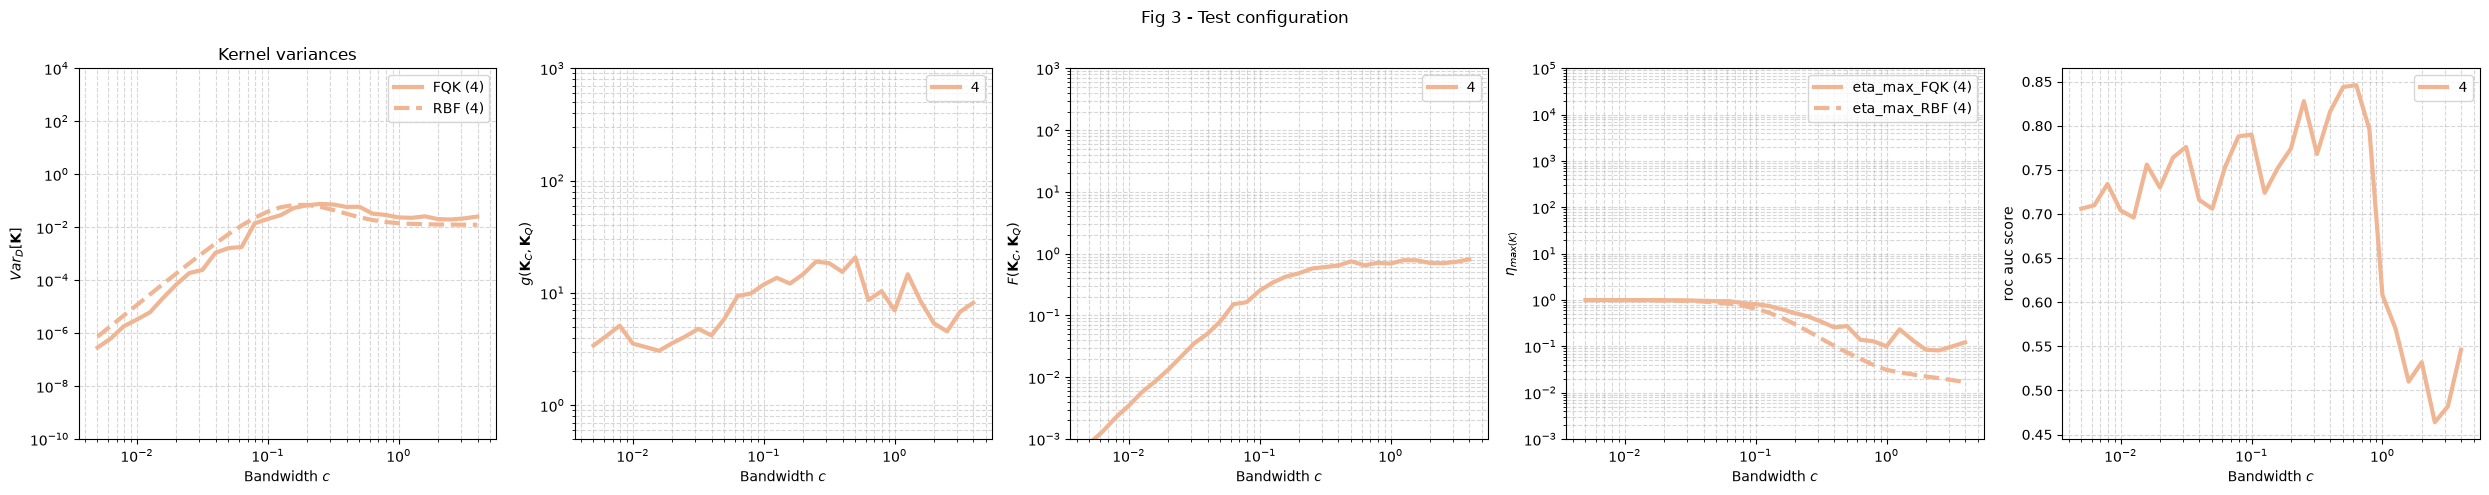

In [5]:
plot_experiment_summaries(cfg, experiment_summaries)


## Customization



To explore another setup, edit `cfg` in Cell 3 and rerun Cells 4 to 6.



Useful changes:



- switch `cfg["dataset"]["name"]` to `fashion_mnist`, `hidden_manifold`, or `plasticc`

- change `cfg["experiments"]` to match one of the JSON files in `configs/`

- reduce `nb_seeds` or `number_of_points` if you want a quicker run



For `plasticc`, the current project loader uses the OpenML anomaly dataset fallback, so it is binary rather than the full multiclass PLAsTiCC challenge dataset.
